<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_python/da05_seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# tips 데이터프레임

In [2]:
tips = sns.load_dataset(name='tips')

In [3]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


# Box Plot

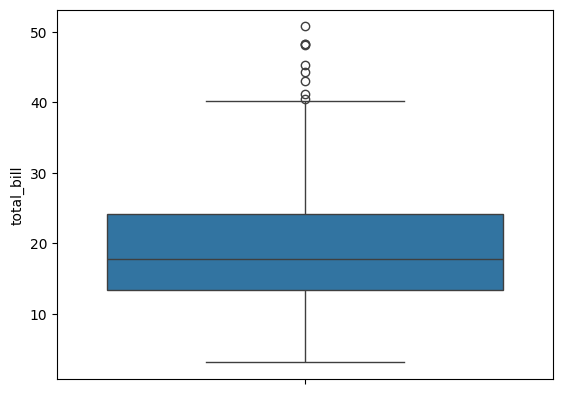

In [8]:
# total_bill box plot
sns.boxplot(data=tips, y='total_bill')
plt.show()

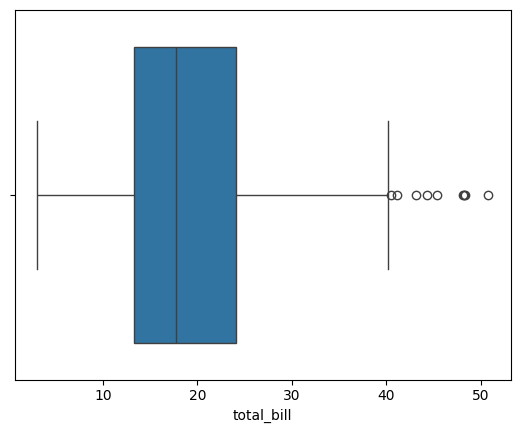

In [9]:
sns.boxplot(data=tips, x='total_bill')
plt.show()

## 성별 tip의 box plot

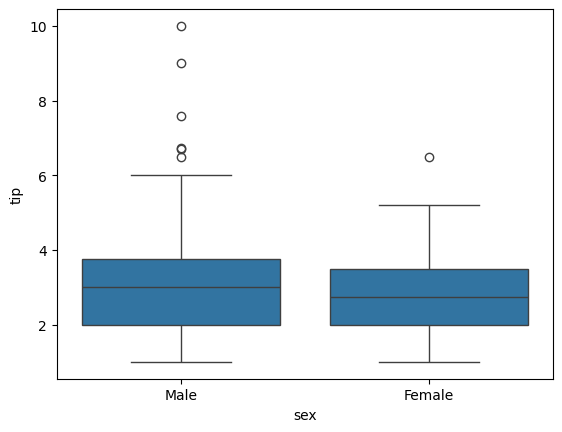

In [10]:
sns.boxplot(data=tips, x='sex', y='tip')
plt.show()

In [12]:
tips.groupby(by='sex', observed=True).tip.describe()

,count,mean,std,min,25%,50%,75%,max
sex,,,,,,,,
Male,157.0,3.089618,1.489102,1.0,2.0,3.00,3.76,10.0
Female,87.0,2.833448,1.159495,1.0,2.0,2.75,3.50,6.5


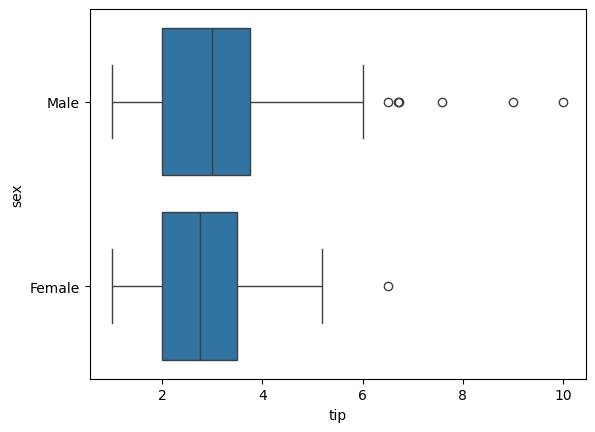

In [13]:
sns.boxplot(data=tips, x='tip', y='sex')
plt.show()

## 요일별 tip box plot

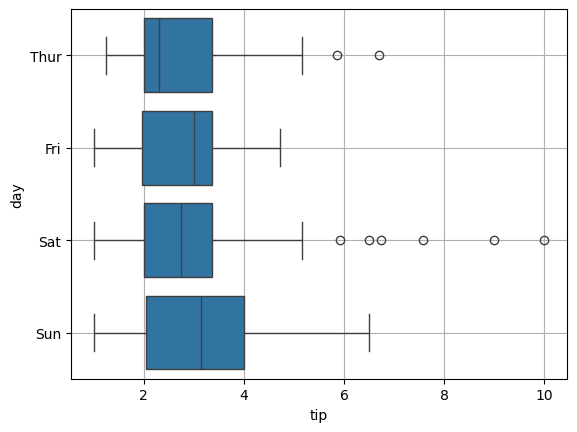

In [15]:
sns.boxplot(data=tips, x='tip', y='day')
plt.grid()
plt.show()

## 요일별 성별 tip box plot

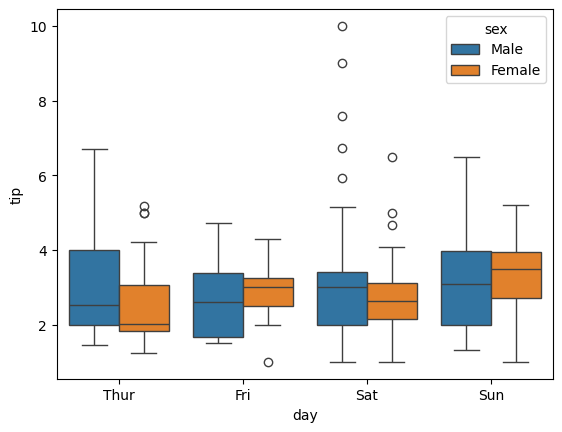

In [16]:
sns.boxplot(data=tips, x='day', y='tip', hue='sex')
plt.show()

In [18]:
tips.groupby(by=['day', 'sex'], observed=True).tip.describe()

count      mean       std   min     25%    50%     75%    max
day  sex                                                                  
Thur Male     30.0  2.980333  1.353734  1.44  2.0000  2.530  4.0000   6.70
     Female   32.0  2.575625  1.109286  1.25  1.8225  2.005  3.0575   5.17
Fri  Male     10.0  2.693000  1.136428  1.50  1.6650  2.600  3.3750   4.73
     Female    9.0  2.781111  0.938862  1.00  2.5000  3.000  3.2500   4.30
Sat  Male     59.0  3.083898  1.791360  1.00  2.0000  3.000  3.4000  10.00
     Female   28.0  2.801786  1.234480  1.00  2.1500  2.625  3.1025   6.50
Sun  Male     58.0  3.220345  1.271172  1.32  2.0000  3.085  3.9800   6.50
     Female   18.0  3.367222  1.136775  1.01  2.7075  3.500  3.9375   5.20

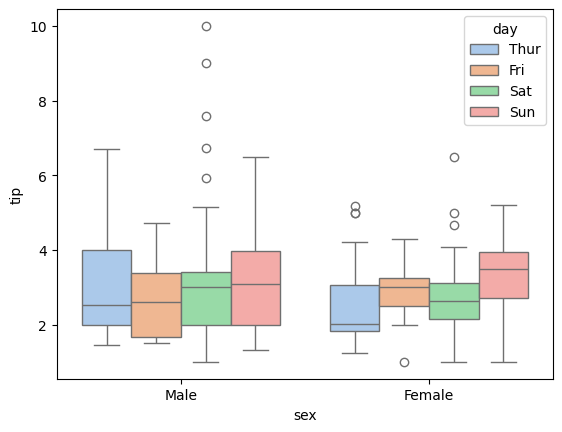

In [20]:
sns.boxplot(data=tips, x='sex', y='tip', hue='day', palette='pastel')
plt.show()

## 2개 이상의 Axes 사용하기

Figure를 2개의 Axes(nrows=1, ncols=2)로 구분, 각각의 Axes에 성별 tip, 시간별 tip box plot.

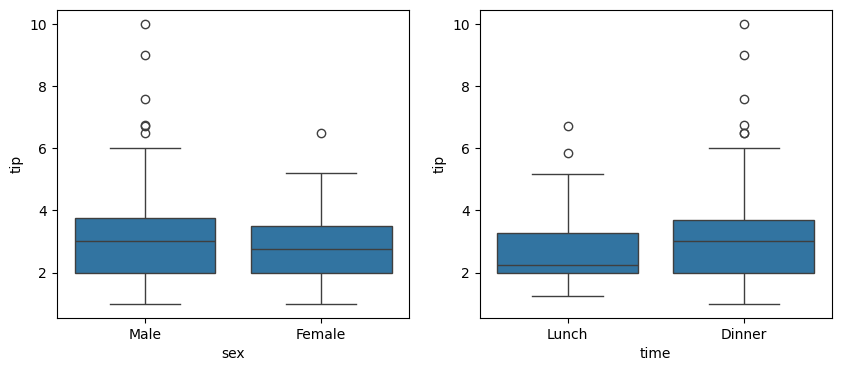

In [26]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 4))

# axes[0]에 성별 tip box plot
sns.boxplot(data=tips, x='sex', y='tip', ax=axes[0])

# axex[1]에 시간별 tip box plot
sns.boxplot(data=tips, x='time', y='tip', ax=axes[1])

plt.show()

# Histogram

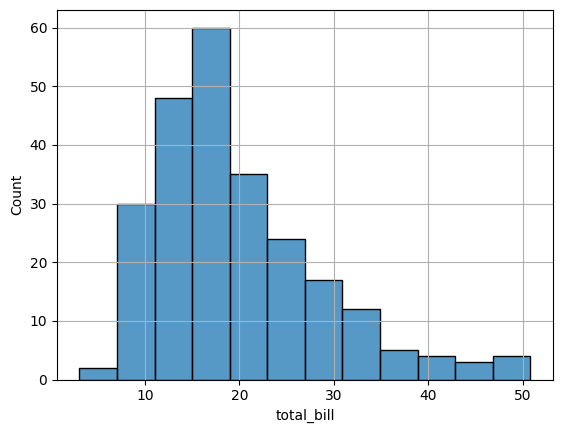

In [31]:
sns.histplot(data=tips, x='total_bill', bins=12)
plt.grid()
plt.show()

Figure를 2개 Axes(nrow=2, ncol=1)로 나누고, 위에는 tip box plot 가로방향으로, 아래쪽에는 tip histogram 그려보세요.

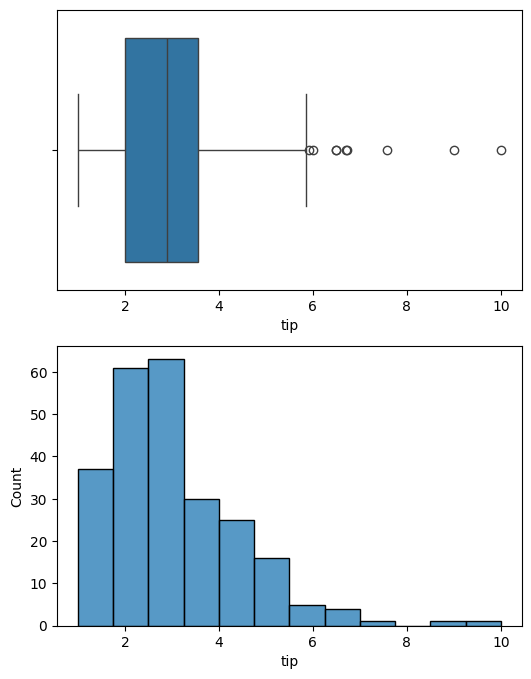

In [38]:
fig, axes = plt.subplots(nrows=2, figsize=(6, 8))

# axes[0]에 tip box plot
sns.boxplot(data=tips, x='tip', ax=axes[0])

# axes[1]에 tip histogram
sns.histplot(data=tips, x='tip', ax=axes[1], bins=12)

plt.show()

# 막대 그래프

## `countplot()` 함수

카테고리(범주) 변수의 빈도수를 막대로 시각화.

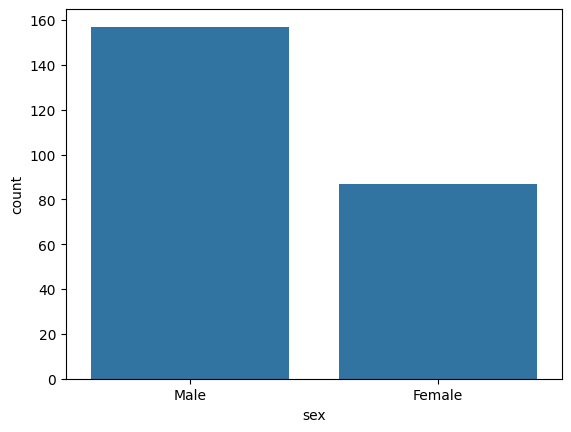

In [41]:
sns.countplot(data=tips, x='sex')
plt.show()

In [42]:
tips.sex.value_counts()

,count
sex,
Male,157
Female,87


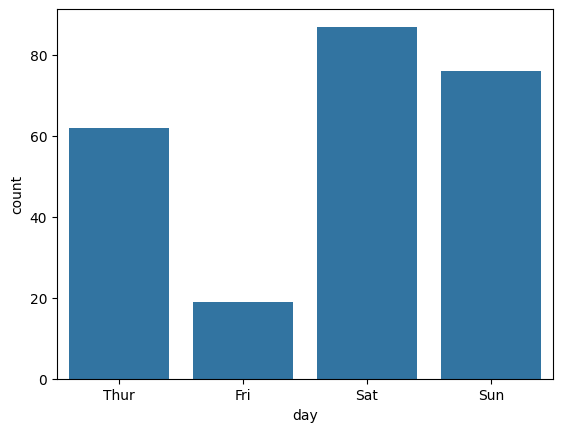

In [43]:
# 요일 빈도수
sns.countplot(data=tips, x='day')
plt.show()

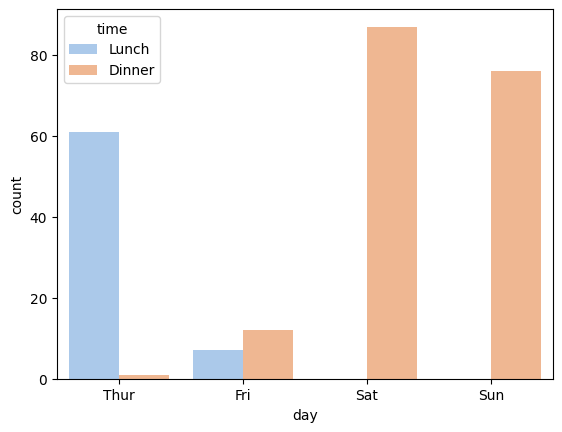

In [45]:
# 요일별 시간별 빈도수
sns.countplot(data=tips, x='day', hue='time', palette='pastel')
plt.show()

In [49]:
tips.groupby(by=['day', 'time'], observed=False).time.count()
#> groupby 메서드의 observed 파라미터 의미:
#> observed=True: 값이 있는 그룹(값이 null 또는 0이 아닌 그룹)만 결과로 리턴.
#> observed=False: 값이 없는 그룹(값이 null 또는 0인 그룹)도 결과로 리턴.

day   time  
Thur  Lunch     61
      Dinner     1
Fri   Lunch      7
      Dinner    12
Sat   Lunch      0
      Dinner    87
Sun   Lunch      0
      Dinner    76
Name: time, dtype: int64

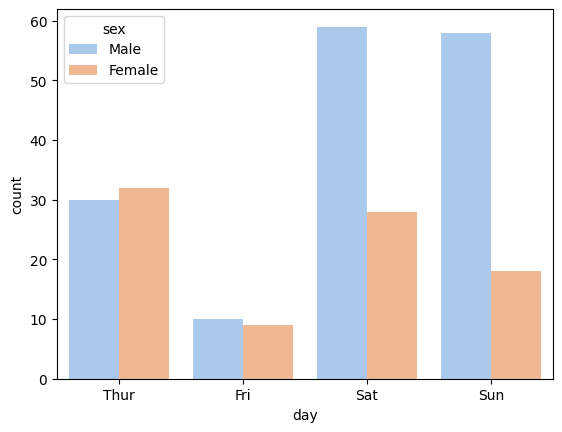

In [51]:
# 요일별 성별 빈도수
sns.countplot(data=tips, x='day', hue='sex', palette='pastel')
plt.show()

In [53]:
tips.groupby(by=['day', 'sex'], observed=True).sex.count()

day   sex   
Thur  Male      30
      Female    32
Fri   Male      10
      Female     9
Sat   Male      59
      Female    28
Sun   Male      58
      Female    18
Name: sex, dtype: int64

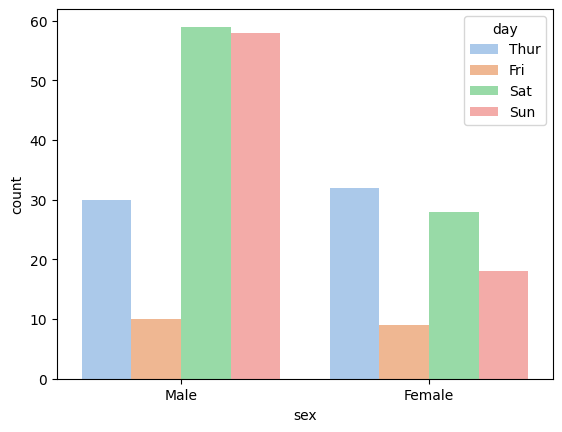

In [54]:
sns.countplot(data=tips, x='sex', hue='day', palette='pastel')
plt.show()

In [56]:
tips.groupby(by=['sex', 'day'], observed=True).day.count()

sex     day 
Male    Thur    30
        Fri     10
        Sat     59
        Sun     58
Female  Thur    32
        Fri      9
        Sat     28
        Sun     18
Name: day, dtype: int64

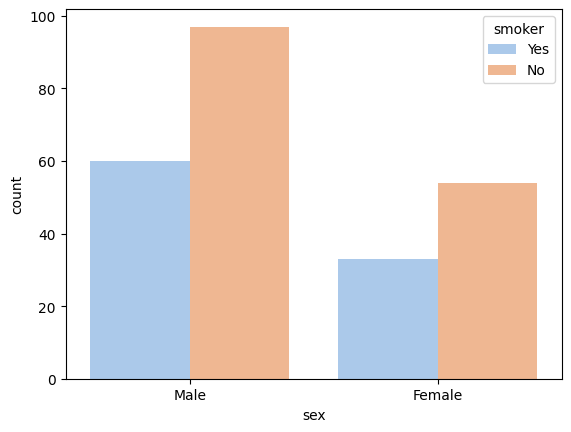

In [59]:
# 성별 흡연여부별 빈도수
sns.countplot(data=tips, x='sex', hue='smoker', palette='pastel')
plt.show()

In [60]:
tips.groupby(by=['sex', 'smoker'], observed=True).smoker.count()

sex     smoker
Male    Yes       60
        No        97
Female  Yes       33
        No        54
Name: smoker, dtype: int64

## `barplot()` 함수

*   그룹별 (연속형) 자료의 기술 통계량(개수, 평균, 최댓값, 중앙값, ...)을 막대로 시각화.
*   카테고리 변수와 연속형 변수를 함께 시각화.

In [62]:
# 성별 팁 평균
tips.groupby(by='sex', observed=True).tip.mean()

,tip
sex,
Male,3.089618
Female,2.833448


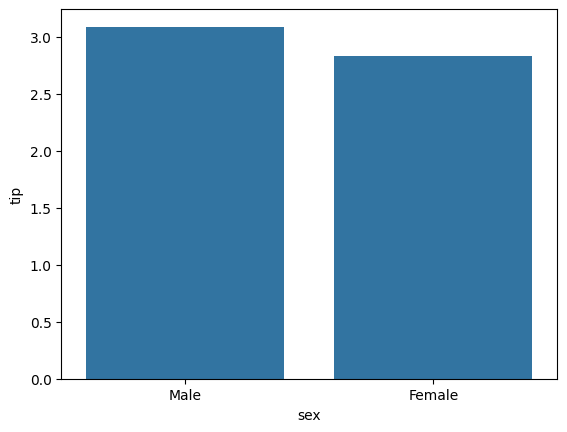

In [64]:
sns.barplot(data=tips, x='sex', y='tip', errorbar=None)
#> barplot() 함수의 estimator 파라미터 기본값은 'mean'(평균).
plt.show()

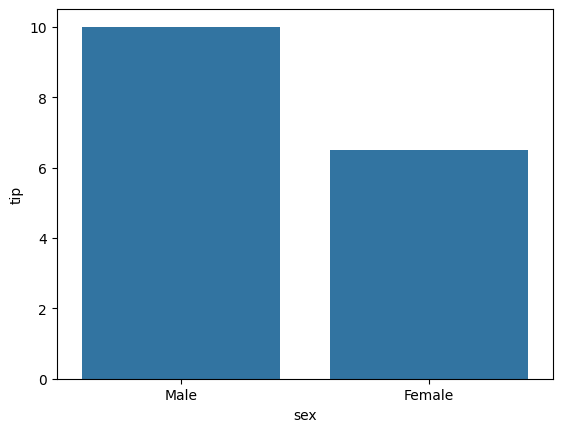

In [65]:
# 성별 팁 최댓값 막대 그래프
sns.barplot(data=tips, x='sex', y='tip', estimator='max', errorbar=None)
plt.show()

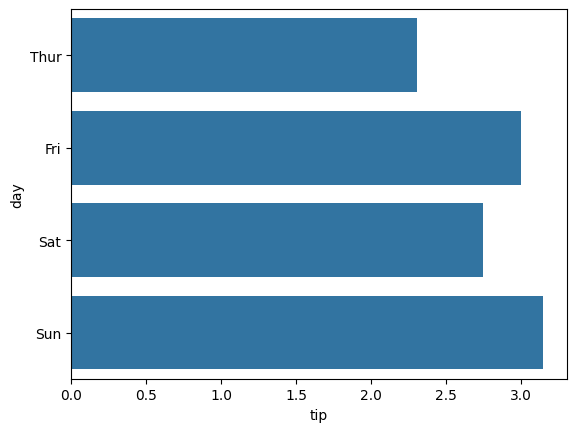

In [66]:
# 요일별 팁 중앙값 가로 막대 그래프
sns.barplot(data=tips, x='tip', y='day', estimator='median', errorbar=None)
plt.show()

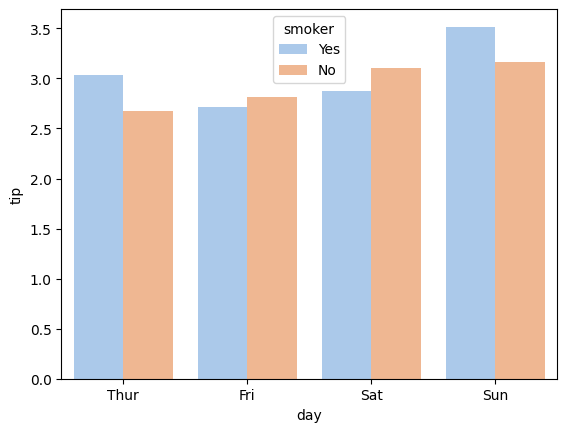

In [70]:
# 요일별 흡연여부별 팁의 평균 막대 그래프
sns.barplot(data=tips, x='day', y='tip', hue='smoker', errorbar=None, palette='pastel')
plt.show()

In [69]:
tips.groupby(by=['day', 'smoker'], observed=True).tip.mean()

day   smoker
Thur  Yes       3.030000
      No        2.673778
Fri   Yes       2.714000
      No        2.812500
Sat   Yes       2.875476
      No        3.102889
Sun   Yes       3.516842
      No        3.167895
Name: tip, dtype: float64

# 산점도(Scatter plot)

## `scatterplot()` 함수

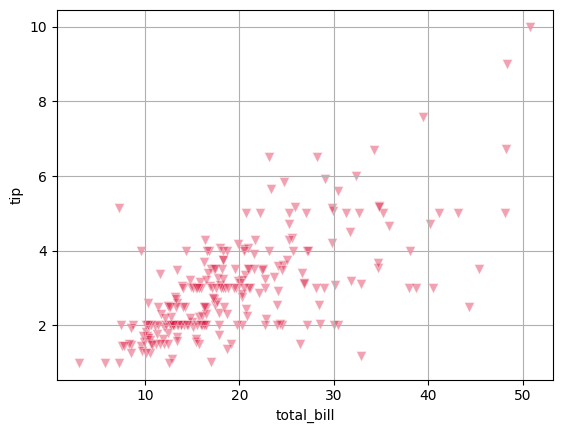

In [86]:
# tip ~ total_bill 산점도
sns.scatterplot(data=tips, x='total_bill', y='tip',
                s=50, c='crimson', marker='v', alpha=0.4)
# s: 마커 크기. c: 마커 색깔. marker: 마커 종류. alpha: 불투명도.
plt.grid()
plt.show()

## `regplot()` 함수

regression plot(회귀선) + scatter plot(산점도)

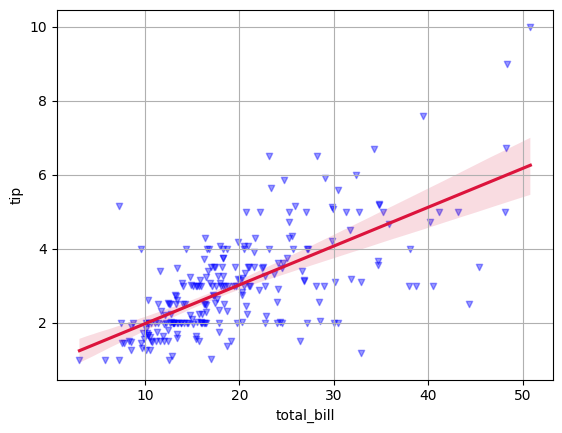

In [101]:
sns.regplot(data=tips, x='total_bill', y='tip',
            marker='v',
            scatter_kws={'s': 20, 'alpha': 0.4, 'color': 'blue'},
            line_kws={'color': 'crimson'})
#> regplot 함수 파라미터
#> scatter_kws: 산점도의 옵션(설정)을 변경하기 위한 값(dict 타입).
#> line_kws: 선형회귀선의 옵션을 변경하기 위한 값(dict).
plt.grid()
plt.show()

## `jointplot()` 함수

산점도 + 히스토그램

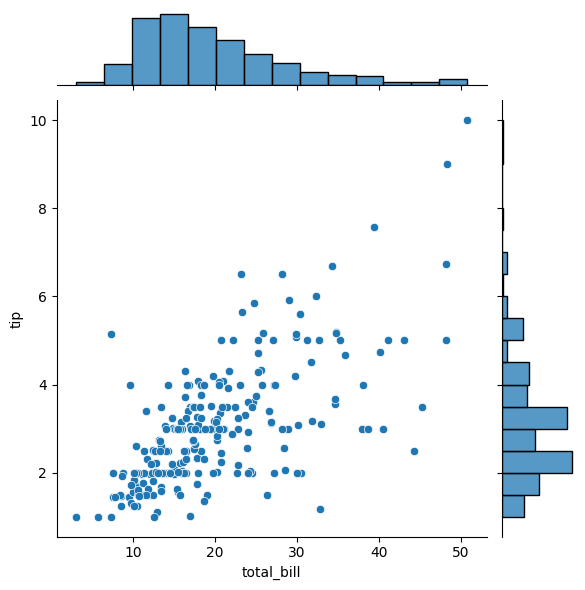

In [102]:
sns.jointplot(data=tips, x='total_bill', y='tip')
plt.show()

## Ex. 1

tip ~ total_bill 산점도. 마커의 색깔을 성별에 따라서 다르게 시각화.

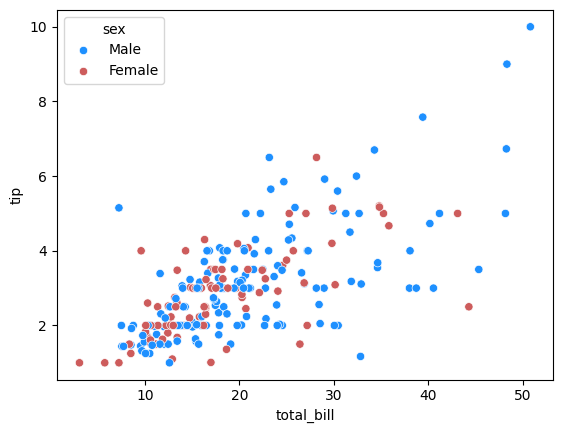

In [110]:
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex',
                # palette='dark'  # deep, muted, bright, dark, pastel, ...
                palette=['DodgerBlue', 'IndianRed'])
plt.show()

## Ex. 2

tip ~ total_bill 산점도. 마커 색깔은 성별에 따라서 다르게, 마커의 크기를 size에 따라서 다르게 시각화.

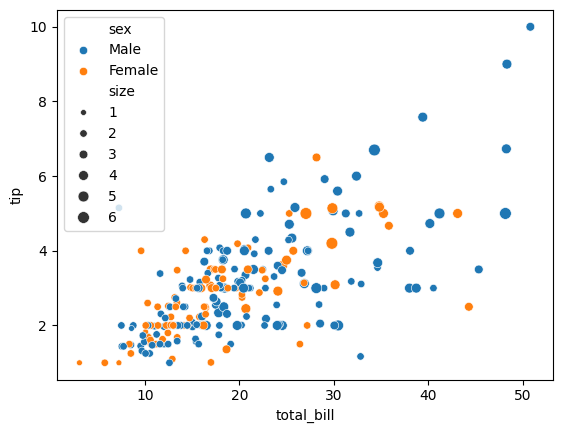

In [111]:
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', size='size')
plt.show()

## Ex. 3

tip ~ total_bill 산점도. 마커 색깔은 성별에 따라서 다르게, 마커 모양은 흡연 여부에 따라서 다르게 시각화.

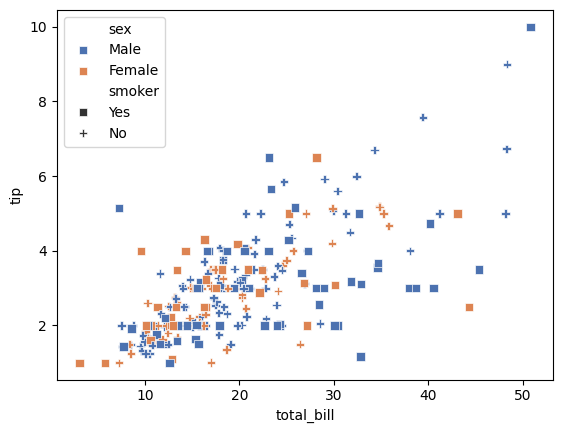

In [120]:
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='sex', palette='deep',
                style='smoker', markers=['s', 'P'])
plt.show()

# Line plot(선 그래프)

In [121]:
np.random.seed(42)
df = pd.DataFrame(data={
    'day': np.arange(1, 31),
    'price': np.random.rand(30),
})

In [122]:
df.head()

,day,price
0,1,0.374540
1,2,0.950714
2,3,0.731994
3,4,0.598658
4,5,0.156019


In [123]:
df.tail()

,day,price
25,26,0.785176
26,27,0.199674
27,28,0.514234
28,29,0.592415
29,30,0.046450


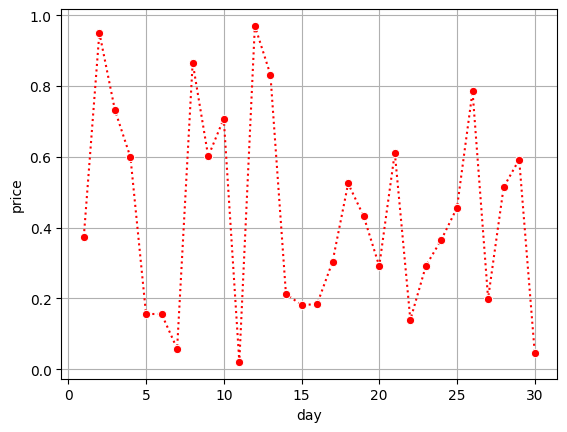

In [134]:
sns.lineplot(data=df, x='day', y='price',
             marker='o', linestyle=':', color='red')
plt.grid()
plt.show()

# Category Plot(`catplot()` 함수)

카테고리 별로 Axes 객체를 생성하고, 변수의 통계값을 모든 Axes에 같은 종류의 그래프로 시각화.

*   요일(x축)별 팁(y축) 평균 막대 그래프
*   성별(Axes 행)과 흡연여부별(Axes 열)로 Axes들을 나눠서 시각화.

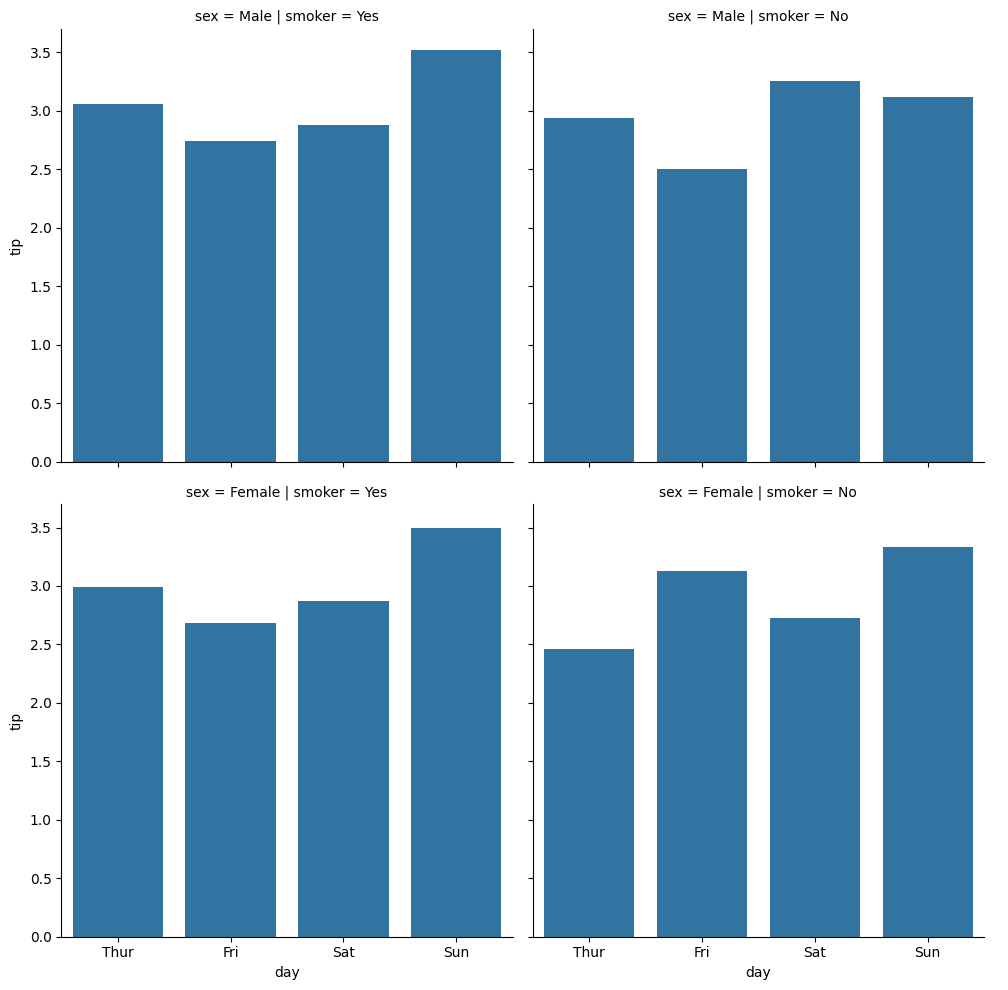

In [138]:
sns.catplot(data=tips, x='day', y='tip',
            row='sex', col='smoker', kind='bar', errorbar=None)
# kind: 그래프(plot) 종류
# estimator: 통계 함수 이름. 기본값은 'mean'.
plt.show()